In [1]:
import os

import cupy as cp
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
num_devices = cp.cuda.runtime.getDeviceCount()
print(f"Total available devices: {num_devices}\n")

for device_id in range(num_devices):
    with cp.cuda.Device(device_id) as dev:
        props = cp.cuda.runtime.getDeviceProperties(device_id)
        name = props['name'].decode('utf-8')
        cc = dev.compute_capability
        print(f"Device {device_id}: {name}")
        print(f"  - Compute Capability: {cc}")

Total available devices: 1

Device 0: NVIDIA GeForce GTX 1060 6GB
  - Compute Capability: 61


## Overall distribution of data in the GPU

Threads: always set to the maximum of 1024 (pixels at once).\
Blocks: the remaining pixels will be distributed across different blocks, always in X to ease the process

Using the `height_index` we can distinguish which line to apply the transformation

---

Original Image Shape:  (1065, 339)
Cropped Image Shape:  (1024, 256)
n threads:  1024
n blocks:  64


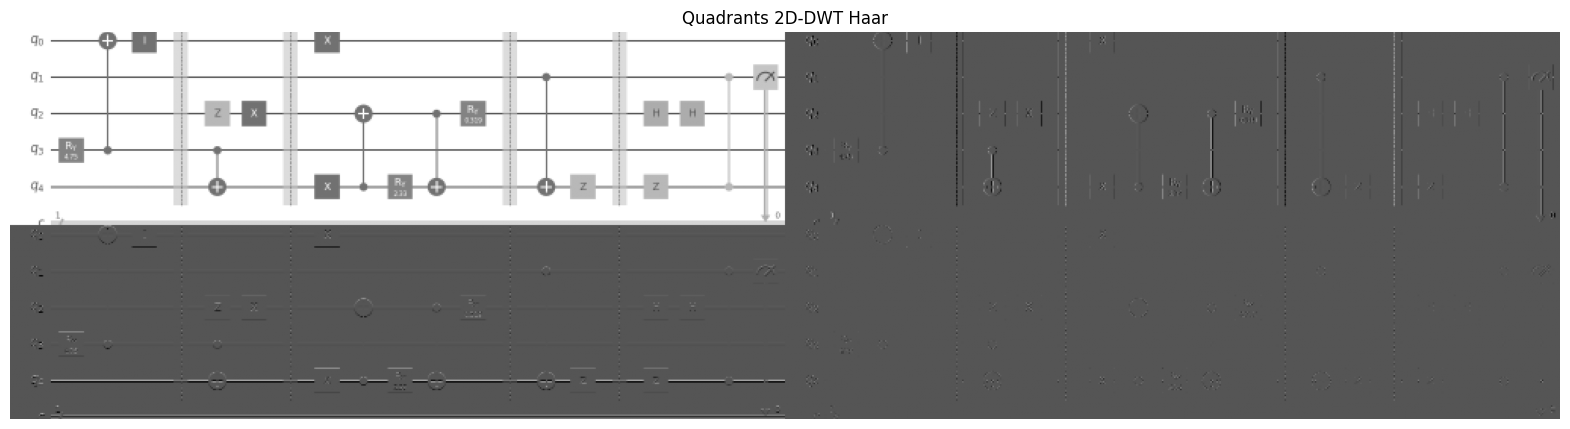

In [3]:
kernel = r"""
extern "C"{
    __global__ void dtw2(
                    const float* input, 
                    float* out, 
                    unsigned int quadrant_width,
                    unsigned int quadrant_height,
                    unsigned int img_width,
                    unsigned int max_pixels_quadrant
    ){
        // the total is width*height, being 1024 threads per block
        unsigned int global_index = (blockIdx.x * blockDim.x) + threadIdx.x;
        if(global_index >= max_pixels_quadrant)
            return;

        // indexes based on the threads indexing
        // thinking like half of the image (a quadrant)
        unsigned int width_index = global_index % quadrant_width;   // internal array
        unsigned int height_index = global_index / quadrant_width;  // external array (height/y)

        unsigned int original_img_w_index = width_index * 2;
        unsigned int original_img_h_index = height_index * 2;

        unsigned int curr_input_index = (original_img_h_index * img_width) + original_img_w_index;
        unsigned int curr_input_index_row = ((original_img_h_index+1) * img_width) + original_img_w_index;
        
        float A_val = 0.5 * (input[curr_input_index] + input[curr_input_index+1] + input[curr_input_index_row] + input[curr_input_index_row+1]);
        float B_val = 0.5 * (input[curr_input_index] - input[curr_input_index+1] + input[curr_input_index_row] - input[curr_input_index_row+1]);
        float C_val = 0.5 * (input[curr_input_index] + input[curr_input_index+1] - input[curr_input_index_row] - input[curr_input_index_row+1]);
        float D_val = 0.5 * (input[curr_input_index] - input[curr_input_index+1] - input[curr_input_index_row] + input[curr_input_index_row+1]);

        unsigned int first_quadrants_row = (height_index * img_width) + width_index;
        unsigned int second_quadrants_row = ((height_index + quadrant_height) * img_width) + width_index;
        
        out[first_quadrants_row] = A_val;
        out[first_quadrants_row + quadrant_width] = B_val;
        out[second_quadrants_row] = C_val;
        out[second_quadrants_row + quadrant_width] = D_val;
    }
};
"""

dtw2 = cp.RawKernel(kernel, "dtw2")

oimg = Image.open(os.path.join("..", "data", "images", "1.png")).convert('L')
print("Original Image Shape: ", oimg.size)

W = 1024
H = 256

left = (oimg.width - W) // 2
top = (oimg.height - H) // 2
right = left + W
bottom = top + H
cropped = oimg.crop((left, top, right, bottom))

print("Cropped Image Shape: ", cropped.size)

ex_img = cp.asarray(cropped,dtype=cp.float32)
out = cp.zeros((H,W), dtype=cp.float32)

QUADRANT_W = W//2
QUADRANT_H = H//2

N_THREADS = 1024

num_blocks = int(np.ceil((QUADRANT_W*QUADRANT_H)/N_THREADS))
print("n threads: ", N_THREADS)
print("n blocks: ", num_blocks)

dtw2((num_blocks,), (N_THREADS,), (ex_img, out, QUADRANT_W, QUADRANT_H, W, QUADRANT_W*QUADRANT_H))
cp.cuda.runtime.deviceSynchronize()

plt.figure(figsize=(20,10))
plt.imshow(out.get().reshape((H,W)), cmap="grey")
plt.axis("off")
plt.title("Quadrants 2D-DWT Haar")
plt.savefig(os.path.join("out","quadrants-2ddwt-haar-cupy.png"), bbox_inches="tight")
plt.show()


Original Image Shape:  (1065, 339)
Cropped Image Shape:  (1024, 256)
n threads:  1024
n blocks:  64


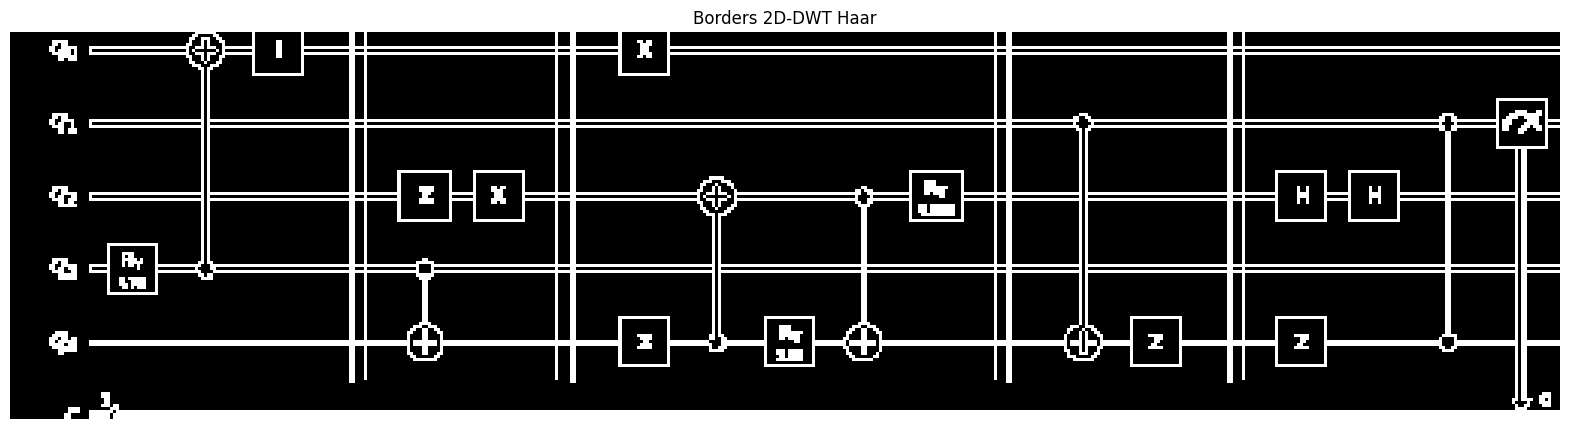

In [4]:
kernel = r"""
extern "C"{
    __global__ void dtw2_borders(
                    const unsigned int* input, 
                    unsigned char* out, 
                    unsigned int quadrant_width,
                    unsigned int img_width,
                    unsigned int max_pixels_quadrant
    ){
        // the total is width*height, being 1024 threads per block
        unsigned int global_index = (blockIdx.x * blockDim.x) + threadIdx.x;
        if(global_index >= max_pixels_quadrant)
            return;

        // indexes based on the threads indexing
        // thinking like half of the image (a quadrant)
        unsigned int width_index = global_index % quadrant_width;   // internal array
        unsigned int height_index = global_index / quadrant_width;  // external array (height/y)

        unsigned int original_img_w_index = width_index * 2;
        unsigned int original_img_h_index = height_index * 2;

        unsigned int curr_input_index = (original_img_h_index * img_width) + original_img_w_index;
        unsigned int curr_input_index_row = ((original_img_h_index+1) * img_width) + original_img_w_index;
        
        float B_val = 0.5 * (input[curr_input_index] - input[curr_input_index+1] + input[curr_input_index_row] - input[curr_input_index_row+1]);
        float C_val = 0.5 * (input[curr_input_index] + input[curr_input_index+1] - input[curr_input_index_row] - input[curr_input_index_row+1]);
        float sum = abs(B_val + C_val);
        
        out[(height_index * quadrant_width) + width_index] = (unsigned char) (sum > 0.5 ? 1 : 0);
    }
};
"""

dtw2_borders = cp.RawKernel(kernel, "dtw2_borders")

oimg = Image.open(os.path.join("..", "data", "images", "1.png")).convert('L')
print("Original Image Shape: ", oimg.size)

W = 1024
H = 256

left = (oimg.width - W) // 2
top = (oimg.height - H) // 2
right = left + W
bottom = top + H
cropped = oimg.crop((left, top, right, bottom))

print("Cropped Image Shape: ", cropped.size)

ex_img = cp.asarray(cropped,dtype=cp.uint32)

QUADRANT_W = W//2
QUADRANT_H = H//2
out = cp.zeros((QUADRANT_H,QUADRANT_W), dtype=cp.uint8)

N_THREADS = 1024

num_blocks = int(np.ceil((QUADRANT_W*QUADRANT_H)/N_THREADS))
print("n threads: ", N_THREADS)
print("n blocks: ", num_blocks)

dtw2_borders((num_blocks,), (N_THREADS,), (ex_img, out, QUADRANT_W, W, QUADRANT_W*QUADRANT_H))
cp.cuda.runtime.deviceSynchronize()

plt.figure(figsize=(20,10))
plt.imshow(out.get().reshape((QUADRANT_H,QUADRANT_W)), cmap="grey")
plt.axis("off")
plt.title("Borders 2D-DWT Haar")
plt.savefig(os.path.join("out","borders-2ddwt-haar-cupy.png"), bbox_inches="tight")
plt.show()


Original Image Shape:  (1065, 339)
n threads:  1024
n blocks:  89


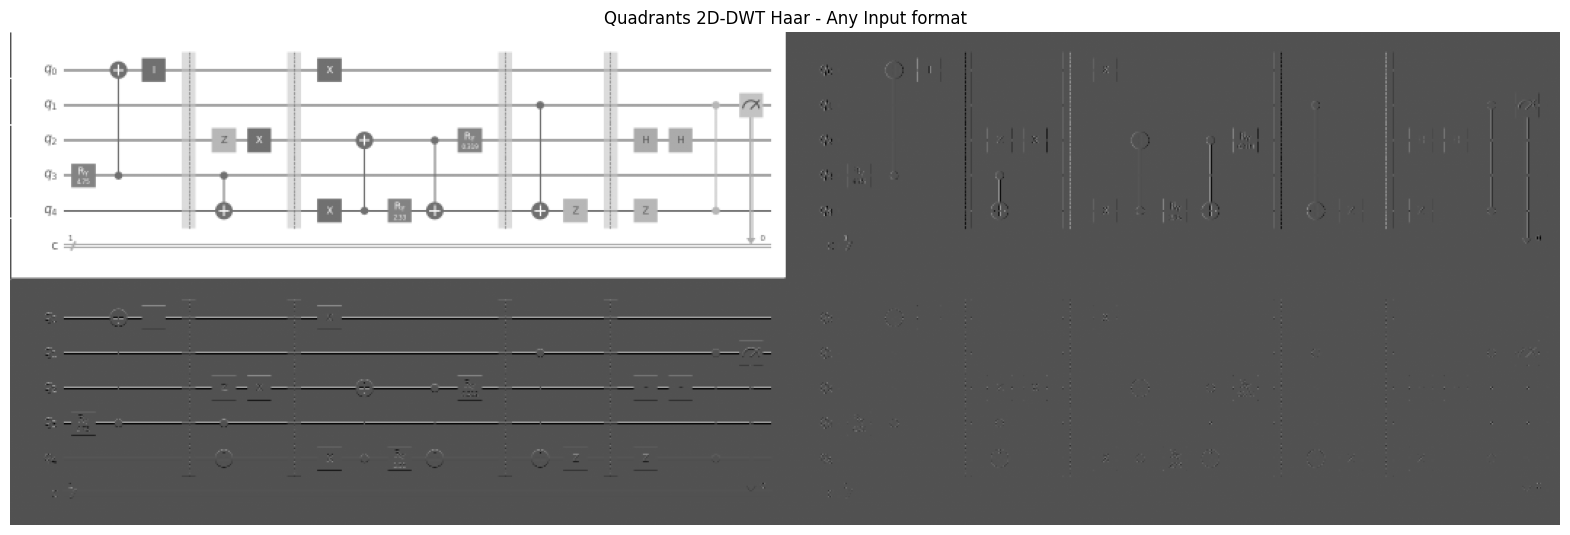

In [5]:
kernel = r"""
extern "C"{
    __global__ void dtw2_any_format(
                    const float* input, 
                    float* out, 
                    unsigned int quadrant_width,
                    unsigned int quadrant_height,
                    unsigned int img_width,
                    unsigned int max_pixels_quadrant,
                    unsigned int max_pixels_image
    ){
        unsigned int global_index = (blockIdx.x * blockDim.x) + threadIdx.x;
        if(global_index >= max_pixels_quadrant)
            return;

        unsigned int width_index = global_index % quadrant_width;   // internal array
        unsigned int height_index = global_index / quadrant_width;  // external array (height/y)

        unsigned int original_img_w_index = width_index * 2;
        unsigned int original_img_h_index = height_index * 2;

        unsigned int curr_input_index = (original_img_h_index * img_width) + original_img_w_index;
        unsigned int curr_input_index_row = ((original_img_h_index+1) * img_width) + original_img_w_index;

        float current_pixel  = curr_input_index >= max_pixels_image ? 1.0 : input[curr_input_index];
        float next_col_pixel = (curr_input_index+1) >= max_pixels_image ? 1.0 : input[curr_input_index+1];
        float next_row_pixel = curr_input_index_row >= max_pixels_image ? 1.0 : input[curr_input_index_row];
        float diag_pixel     = (curr_input_index_row+1) >= max_pixels_image ? 1.0 : input[curr_input_index_row+1];
        
        float A_val = 0.5 * (current_pixel + next_col_pixel + next_row_pixel + diag_pixel);
        float B_val = 0.5 * (current_pixel - next_col_pixel + next_row_pixel - diag_pixel);
        float C_val = 0.5 * (current_pixel + next_col_pixel - next_row_pixel - diag_pixel);
        float D_val = 0.5 * (current_pixel - next_col_pixel - next_row_pixel + diag_pixel);

        unsigned int first_quadrants_row = (height_index * img_width) + width_index;
        unsigned int second_quadrants_row = ((height_index + quadrant_height) * img_width) + width_index;
        
        out[first_quadrants_row] = A_val;
        out[first_quadrants_row + quadrant_width] = B_val;
        out[second_quadrants_row] = C_val;
        out[second_quadrants_row + quadrant_width] = D_val;
    }
};
"""

dtw2_any_format = cp.RawKernel(kernel, "dtw2_any_format")

oimg = Image.open(os.path.join("..", "data", "images", "1.png")).convert('L')
print("Original Image Shape: ", oimg.size)

W,H = oimg.size
ex_img = cp.asarray(oimg,dtype=cp.float32)
out = cp.zeros((H,W), dtype=cp.float32)

QUADRANT_W = int(np.ceil(W/2))
QUADRANT_H = int(np.ceil(H/2))

N_THREADS = 1024

num_blocks = int(np.ceil((QUADRANT_W*QUADRANT_H)/N_THREADS))
print("n threads: ", N_THREADS)
print("n blocks: ", num_blocks)

dtw2_any_format((num_blocks,), (N_THREADS,), (ex_img, out, QUADRANT_W, QUADRANT_H, W, QUADRANT_W*QUADRANT_H, W*H))
cp.cuda.runtime.deviceSynchronize()

plt.figure(figsize=(20,10))
plt.imshow(out.get().reshape((H,W)), cmap="grey")
plt.axis("off")
plt.title("Quadrants 2D-DWT Haar - Any Input format")
plt.savefig(os.path.join("out","quadrants-2ddwt-haar-any-formatcupy.png"), bbox_inches="tight")
plt.show()


Original Image Shape:  (1065, 339)
n threads:  1024
n blocks:  89


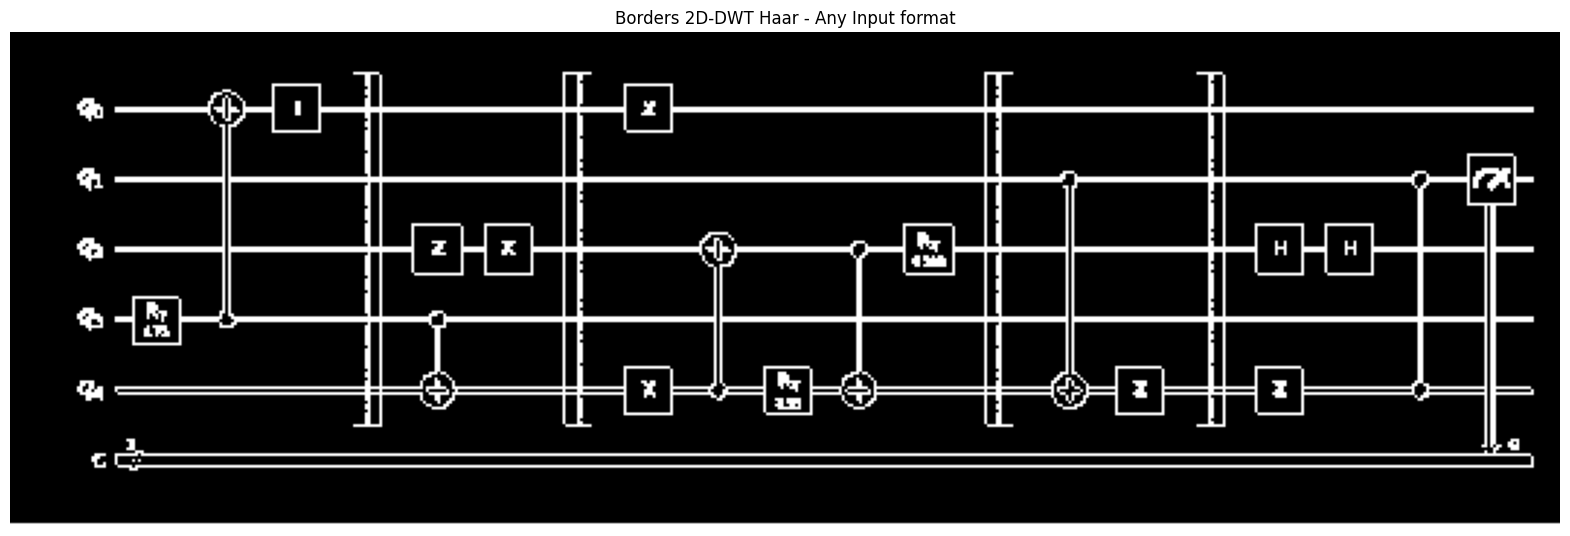

In [6]:
kernel = r"""
extern "C"{
    __global__ void dtw2_borders_any_format(
                    const unsigned int* input, 
                    unsigned char* out, 
                    unsigned int quadrant_width,
                    unsigned int img_width,
                    unsigned int max_pixels_quadrant,
                    unsigned int max_pixels_image
    ){
        unsigned int global_index = (blockIdx.x * blockDim.x) + threadIdx.x;
        if(global_index >= max_pixels_quadrant)
            return;

        unsigned int width_index = global_index % quadrant_width;   // internal array
        unsigned int height_index = global_index / quadrant_width;  // external array (height/y)

        unsigned int original_img_w_index = width_index * 2;
        unsigned int original_img_h_index = height_index * 2;

        unsigned int curr_input_index = (original_img_h_index * img_width) + original_img_w_index;
        unsigned int curr_input_index_row = ((original_img_h_index+1) * img_width) + original_img_w_index;

        float current_pixel  = curr_input_index >= max_pixels_image ? 1.0 : input[curr_input_index];
        float next_col_pixel = (curr_input_index+1) >= max_pixels_image ? 1.0 : input[curr_input_index+1];
        float next_row_pixel = curr_input_index_row >= max_pixels_image ? 1.0 : input[curr_input_index_row];
        float diag_pixel     = (curr_input_index_row+1) >= max_pixels_image ? 1.0 : input[curr_input_index_row+1];
        
        float B_val = 0.5 * (current_pixel - next_col_pixel + next_row_pixel - diag_pixel);
        float C_val = 0.5 * (current_pixel + next_col_pixel - next_row_pixel - diag_pixel);
        float sum = abs(B_val + C_val);
        
        out[(height_index * quadrant_width) + width_index] = (unsigned char) (sum > 0.5 ? 1 : 0);
    }
};
"""

dtw2_borders_any_format = cp.RawKernel(kernel, "dtw2_borders_any_format")

oimg = Image.open(os.path.join("..", "data", "images", "1.png")).convert('L')
print("Original Image Shape: ", oimg.size)

W,H = oimg.size
ex_img = cp.asarray(oimg,dtype=cp.uint32)

QUADRANT_W = int(np.ceil(W/2))
QUADRANT_H = int(np.ceil(H/2))
out = cp.zeros((QUADRANT_H,QUADRANT_W), dtype=cp.uint8)

N_THREADS = 1024

num_blocks = int(np.ceil((QUADRANT_W*QUADRANT_H)/N_THREADS))
print("n threads: ", N_THREADS)
print("n blocks: ", num_blocks)

dtw2_borders_any_format((num_blocks,), (N_THREADS,), (ex_img, out, QUADRANT_W, W, QUADRANT_W*QUADRANT_H, W*H))
cp.cuda.runtime.deviceSynchronize()

plt.figure(figsize=(20,10))
plt.imshow(out.get().reshape((QUADRANT_H,QUADRANT_W)), cmap="grey")
plt.axis("off")
plt.title("Borders 2D-DWT Haar - Any Input format")
plt.savefig(os.path.join("out","borders-2ddwt-haar-any-format-cupy.png"), bbox_inches="tight")
plt.show()
